In [4]:
import string
import re
from numpy import array, argmax, random, take
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, RepeatVector
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt

## Loading Data

In [7]:
train = pd.read_parquet('/home/inductive_anks/Machine Learning/Competitions/Zindi-Africa/Machine-Translation/data/raw/train-00000-of-00001.parquet')

In [8]:
test = pd.read_parquet('/home/inductive_anks/Machine Learning/Competitions/Zindi-Africa/Machine-Translation/data/raw/test-00000-of-00001.parquet')

In [9]:
validate = pd.read_parquet('/home/inductive_anks/Machine Learning/Competitions/Zindi-Africa/Machine-Translation/data/raw/validation-00000-of-00001.parquet')

## Preprocessing

In [10]:
def to_lower(df):
    for index, row in df.iterrows():
        dyu_lower = row['translation']['dyu'].lower()
        fr_lower = row['translation']['fr'].lower()
        
        df.at[index, 'translation'] = {'dyu': dyu_lower, 'fr': fr_lower}
    return df

In [13]:
train = to_lower(train)
validate = to_lower(validate)
test = to_lower(test)

In [14]:
test.head()

,ID,translation
0,ID_17345911362699,"{'dyu': 'an kelen duron le tun be yi', 'fr': '0'}"
1,ID_173626847.3381,"{'dyu': 'o ka papiye farana.', 'fr': '0'}"
2,ID_17704632382547,"{'dyu': 'n tɔrɔla kɔ tuguni', 'fr': '0'}"
3,ID_19793499384156,"{'dyu': 'i tun b'a daminɛ tan kɛ.', 'fr': '0'}"
4,ID_17802727385575,"{'dyu': 'a kɛra ka ban.', 'fr': '0'}"


## Distribution of Lengths of the Sentences over the corpus

In [15]:
def calculate_lengths(df):
    eng_l = []
    deu_l = []
    
    for index, row in df.iterrows():
        eng_l.append(len(row['translation']['dyu'].split()))
        deu_l.append(len(row['translation']['fr'].split()))
    
    return eng_l, deu_l

In [29]:
train_fr_len, train_deu_len = calculate_lengths(train)
validate_fr_len, validate_deu_len = calculate_lengths(validate)
test_fr_len, test_deu_len = calculate_lengths(test)

In [30]:
train_length_df = pd.DataFrame({'fr': train_fr_len, 'deu': train_deu_len})
validate_length_df = pd.DataFrame({'fr': validate_fr_len, 'deu': validate_deu_len})
test_length_df = pd.DataFrame({'fr': test_fr_len, 'deu': test_deu_len})

array([[<Axes: title={'center': 'fr'}>, <Axes: title={'center': 'deu'}>]],
      dtype=object)

<Figure size 1800x600 with 0 Axes>

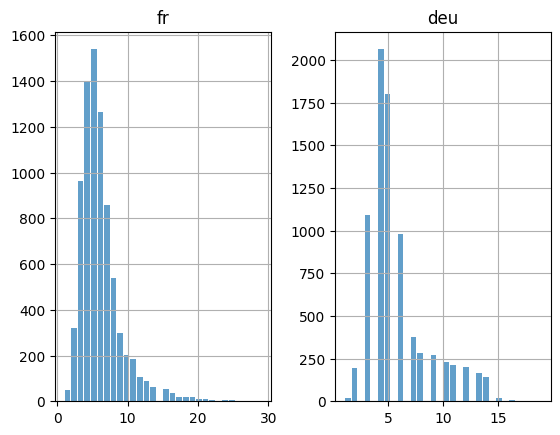

In [35]:
# Train data length of sentences

plt.figure(figsize=(18, 6))
train_length_df.hist(bins=30, alpha=0.7, rwidth=0.85)

array([[<Axes: title={'center': 'fr'}>, <Axes: title={'center': 'deu'}>]],
      dtype=object)

<Figure size 1800x600 with 0 Axes>

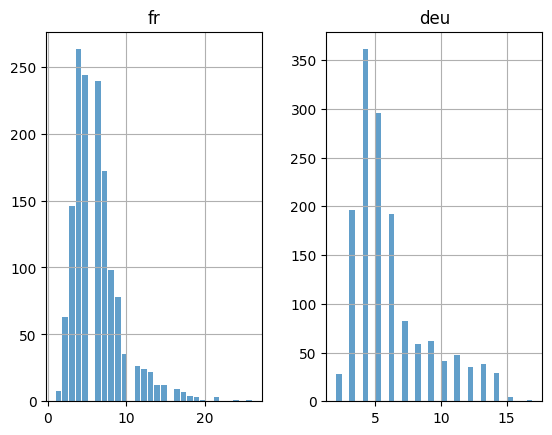

In [36]:
# Validate data length of sentences

plt.figure(figsize=(18, 6))
validate_length_df.hist(bins=30, alpha=0.7, rwidth=0.85)

array([[<Axes: title={'center': 'fr'}>, <Axes: title={'center': 'deu'}>]],
      dtype=object)

<Figure size 1800x600 with 0 Axes>

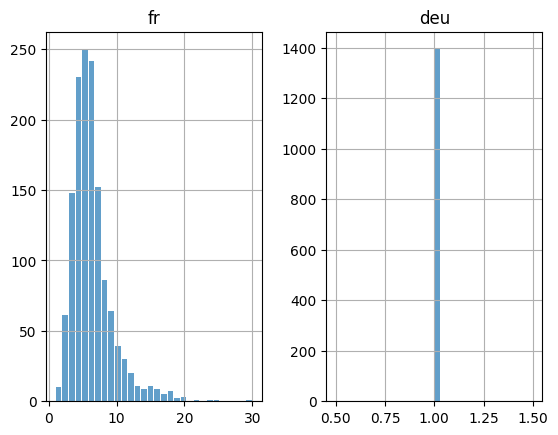

In [37]:
# Test data length of sentences

plt.figure(figsize=(18, 6))
test_length_df.hist(bins=30, alpha=0.7, rwidth=0.85)

## Tokenization into Word Ids

In [38]:
def tokenization(lines):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(lines)
    return tokenizer

In [40]:
train_dyu_lines = [row['translation']['dyu'] for _, row in train.iterrows()]
train_fr_lines = [row['translation']['fr'] for _, row in train.iterrows()]

validate_dyu_lines = [row['translation']['dyu'] for _, row in validate.iterrows()]
validate_fr_lines = [row['translation']['fr'] for _, row in validate.iterrows()]

In [41]:
train_dyu_tokenizer = tokenization(train_dyu_lines)
train_fr_tokenizer = tokenization(train_fr_lines)

validate_dyu_tokenizer = tokenization(validate_dyu_lines)
validate_fr_tokenizer = tokenization(validate_fr_lines)

In [43]:
print(f"Train Dyula tokenizer vocab size: {len(train_dyu_tokenizer.word_index)}")
print(f"Train French tokenizer vocab size: {len(train_fr_tokenizer.word_index)}")
print(f"Validate Dyula tokenizer vocab size: {len(validate_dyu_tokenizer.word_index)}")
print(f"Validate French tokenizer vocab size: {len(validate_fr_tokenizer.word_index)}")

Train Dyula tokenizer vocab size: 7784
Train French tokenizer vocab size: 9805
Validate Dyula tokenizer vocab size: 2445
Validate French tokenizer vocab size: 3060


## Padding and Encodeing

In [44]:
def encode_sequences(tokenizer, length, lines):
    seq = tokenizer.texts_to_sequences(lines)
    # pad sequences with 0 values
    seq = pad_sequences(seq, maxlen=length, padding='post')
    return seq

In [55]:
train_max_length_dyu = max(len(line.split()) for line in train_dyu_lines)

train_max_length_fr = max(len(line.split()) for line in train_fr_lines)

In [56]:
print(f"Max Length of Dyula corpus: {train_max_length_dyu}")
print(f"Max Length of French corpus: {train_max_length_fr}")

Max Length of Dyula corpus: 29
Max Length of French corpus: 19


In [45]:
max_length_dyu = max(max(len(line.split()) for line in train_dyu_lines), 
                     max(len(line.split()) for line in validate_dyu_lines))

max_length_fr = max(max(len(line.split()) for line in train_fr_lines), 
                    max(len(line.split()) for line in validate_fr_lines))


In [48]:
print(f"Max Length of Dyula corpus: {max_length_dyu}")
print(f"Max Length of French corpus: {max_length_fr}")

Max Length of Dyula corpus: 29
Max Length of French corpus: 19


In [49]:
train_dyu_seq = encode_sequences(train_dyu_tokenizer, max_length_dyu, train_dyu_lines)
train_fr_seq = encode_sequences(train_fr_tokenizer, max_length_fr, train_fr_lines)

validate_dyu_seq = encode_sequences(validate_dyu_tokenizer, max_length_dyu, validate_dyu_lines)
validate_fr_seq = encode_sequences(validate_fr_tokenizer, max_length_fr, validate_fr_lines)

## Defining the Model

In [54]:
train_dyu_vocab_size = len(train_dyu_tokenizer.word_index) + 1
train_fr_vocab_size = len(train_fr_tokenizer.word_index) + 1

In [62]:
def define_model(in_vocab,out_vocab, in_timesteps,out_timesteps, units):
    model = Sequential()
    model.add(Embedding(in_vocab, units, input_length=in_timesteps, mask_zero=True))
    model.add(LSTM(units))
    model.add(RepeatVector(out_timesteps))
    model.add(LSTM(units, return_sequences=True))
    model.add(Dense(out_vocab, activation='softmax'))
    return model

In [63]:
# model compilation
model = define_model(train_dyu_vocab_size, train_fr_vocab_size, train_max_length_dyu, train_max_length_fr, 512)

In [64]:
rms = optimizers.RMSprop(learning_rate=0.001)
model.compile(optimizer=rms, loss='sparse_categorical_crossentropy')

In [65]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Filename for saving the model
filename = 'model.h1.24_jan_19.keras'   # Changed extension to .h5 for Keras models

# Define ModelCheckpoint callback
checkpoint = ModelCheckpoint(
    filename,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Train the model
history = model.fit(
    train_dyu_seq,  # Use the encoded train sequences for Dyula as input
    train_fr_seq.reshape(train_fr_seq.shape[0], train_fr_seq.shape[1], 1),  # Reshape train sequences for French
    epochs=30,
    batch_size=512,
    validation_data=(validate_dyu_seq, validate_fr_seq.reshape(validate_fr_seq.shape[0], validate_fr_seq.shape[1], 1)),  # Use validation data
    callbacks=[checkpoint],
    verbose=1
)


Epoch 1/30


2024-08-04 00:10:06.765664: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 381571072 exceeds 10% of free system memory.
2024-08-04 00:10:12.661085: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 10282336256 exceeds 10% of free system memory.


: 